In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
    make_animation,
    metrics_grid,
    plot_grid,
    plot_ball_behavior,
    plot_all_trajectories,
    plot
)
import plotly.express as px
from src.classify import classify_trajectories
from skimage import measure, filters

In [4]:
model = "bruss"
ds_id = "param_sweep"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df = expand_json_column(df, "original_point", "op", True)
df = expand_json_column(df, "initial_condition", "ic", True)
df = classify_trajectories(df)
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [10]:
fig = px.scatter(
    df,
    x="A",
    y="ratio_b_a",
    color="labels",
    opacity=0.7,
    hover_data={"idx": True},
)
fig.update_traces(marker_size=2)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [13]:
df.value_counts("pca_label")

pca_label
1    5884
0    3760
2    1156
Name: count, dtype: int64

In [93]:
def connectedness_score(u_field, sigma=0):
    tau = (u_field.max() + u_field.min()) / 2
    if sigma > 0:
        u_field = filters.gaussian(u_field, sigma=sigma)
    binary = u_field > tau
    labeled = measure.label(binary, connectivity=2)
    plt.imshow(labeled)
    plt.show()
    num_components = np.max(labeled)
    area = binary.shape[0] * binary.shape[1]
    return num_components

In [8]:
df_filt = df[df.pca_label == 0]

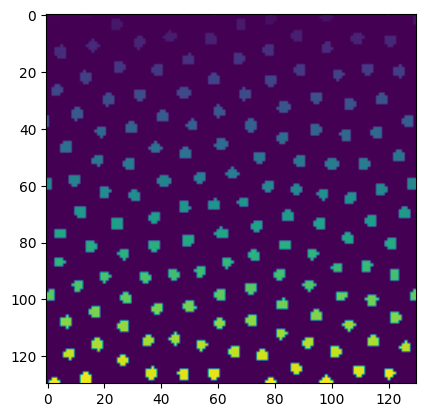

In [94]:
cs = []
for i, row in df_filt.iterrows():
    d = ds.get_data(i)
    u_final = d[-1, :, 0::2]
    cs.append(connectedness_score(u_final))


In [17]:
df_sub = df_filt.copy()
df_sub["is_lab"] = 0
df_sub.loc[df_sub.idx.isin([102, 1104, 1814, 2547, 3365, 3466, 6760, 7333, 7698, 9312, 9520, 10686]), "is_lab"] = 2

In [18]:
fig = px.scatter_3d(
    df_sub,
    x="A",
    y="ratio_b_a",
    z="mean_deviation",
    color="is_lab",
    hover_data={"idx": True},
)
fig.update_traces(marker_size=2)
fig

3984 0.0002958579881656805


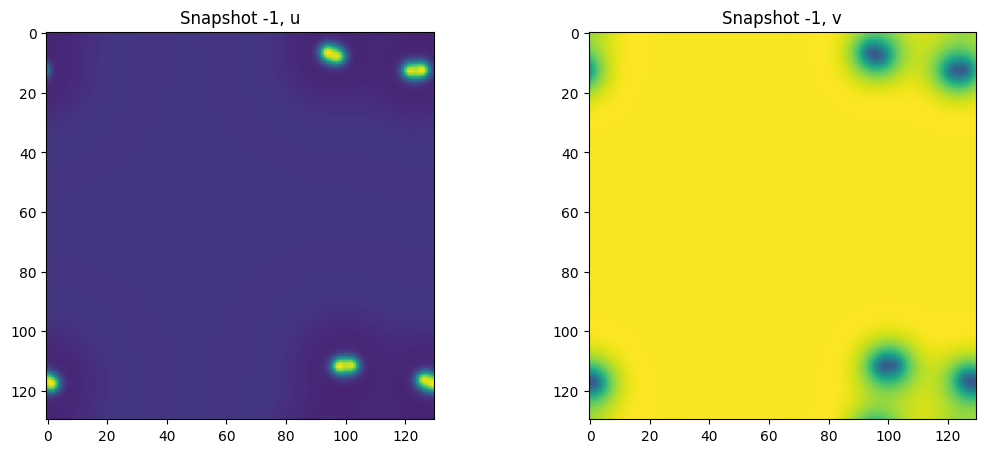

6193 0.0002958579881656805


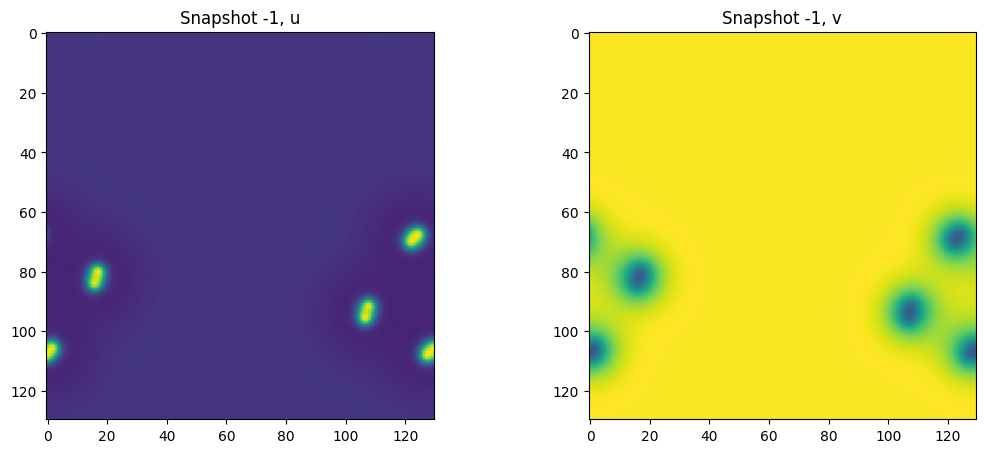

10143 0.00035502958579881655


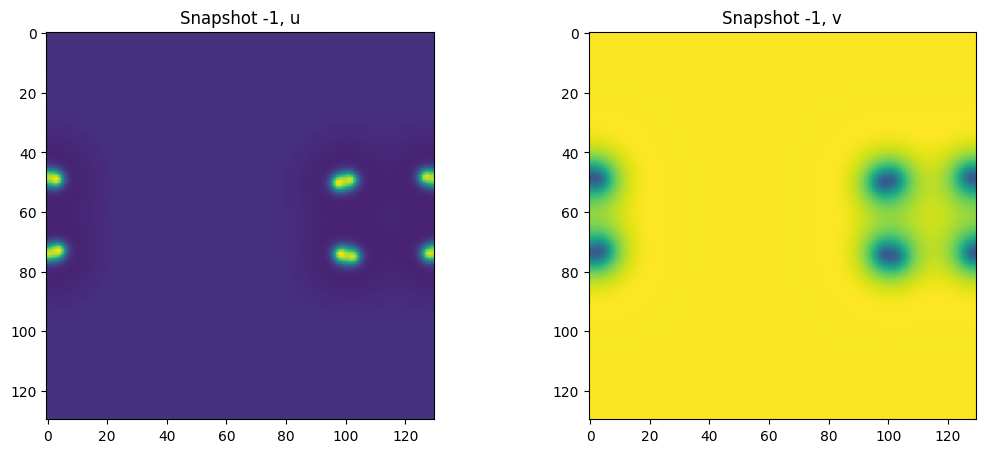

3575 0.00047337278106508875


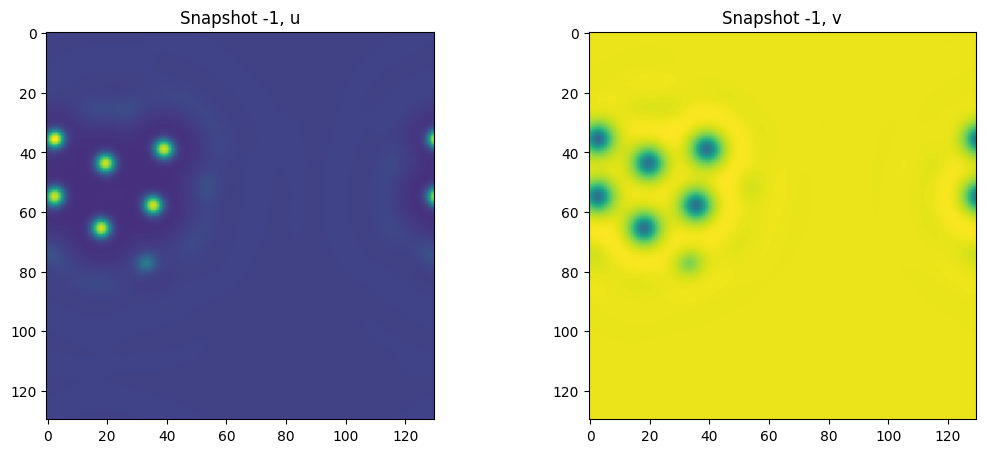

7777 0.0005325443786982248


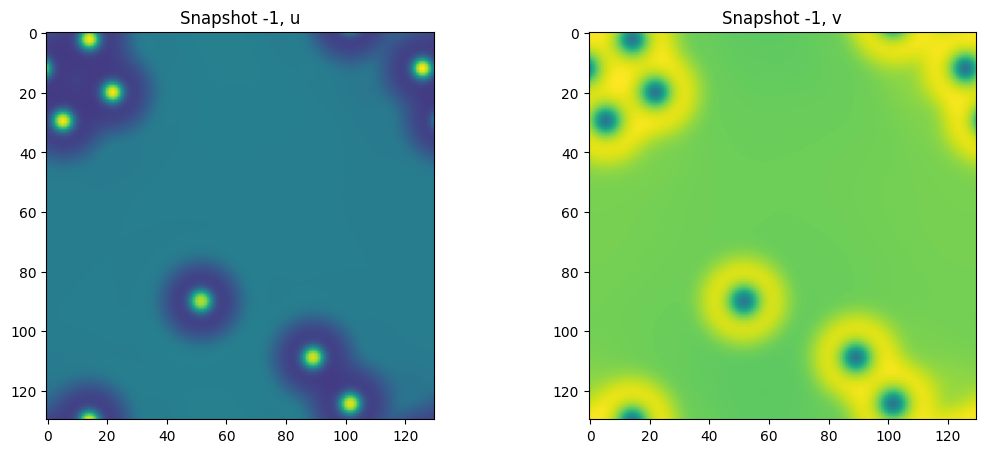

In [64]:
df_sorted = df_sub.sort_values(by='conn')
for i, row in df_sorted.iloc[:5].iterrows():
    d = ds.get_data(i)
    print(i, row["conn"])
    plot(d, 0, np.max(d))
    plt.show()

In [81]:
i = 1664
d = ds.get_data(i)
make_animation(d, str(i), ".")

MovieWriter ffmpeg unavailable; using Pillow instead.
